In [ ]:
#r "FreeXNSE.dll"
#r "BoSSSpad.dll"
using System;
using System.Data;
using System.Collections.Generic;
using System.Linq;
using System.IO;
using ilPSP;
using ilPSP.Utils;
using BoSSS.Platform;
using BoSSS.Foundation;
using BoSSS.Foundation.XDG;
using BoSSS.Foundation.Grid;
using BoSSS.Foundation.Grid.Classic;
using BoSSS.Foundation.IO;
using BoSSS.Solution;
using BoSSS.Solution.Control;
using BoSSS.Solution.GridImport;
using BoSSS.Solution.Statistic;
using BoSSS.Solution.Utils;
using BoSSS.Solution.AdvancedSolvers;
using BoSSS.Solution.Gnuplot;
using BoSSS.Application.BoSSSpad;
using FreeXNSE;
using static BoSSS.Application.BoSSSpad.BoSSSshell;
using System.Diagnostics;
using Microsoft.AspNetCore.Html;
using System.Text.RegularExpressions;

Init();

In [ ]:
string proj = "ContactLineSingularity";
BoSSSshell.WorkflowMgm.Init(proj);
BoSSSshell.WorkflowMgm.SetNameBasedSessionJobControlCorrelation();


In [ ]:
//BoSSSshell.WorkflowMgm.ResetProject(true, true, true, true);

Utility routines to create the control objects.  
Basically a base configuration and easy to use wrapper routines to configure e.g. the contact angle model  

In [ ]:
static GridCommons StaticDropletGrid(int GridRes, double R){
    var _xNodes = GenericBlas.Linspace(-1.1*R, 1.1*R, GridRes + 1);
    var _yNodes = GenericBlas.Linspace(0, 2.2*R, GridRes + 1);

    var grd = Grid2D.Cartesian2DGrid(_xNodes, _yNodes, BoSSS.Foundation.Grid.RefElements.CellType.Square_Linear);

    grd.DefineEdgeTags(delegate (double[] _X) {
        double x = _X[0];
        double y = _X[1];
        if(Math.Abs(y - _yNodes.First()) < 1.0e-12)
            // bottom
            return "Robin_bottom";
        if(Math.Abs(y - _yNodes.Last()) < 1.0e-12)
            // top
            return "Neumann_top";
        if(Math.Abs(x - _xNodes.First()) < 1.0e-12)
            // left
            return "Neumann_left";
        if(Math.Abs(x - _xNodes.Last()) < 1.0e-12)
            // right
            return "Neumann_right";

        throw new ArgumentOutOfRangeException();
    });
    
    grd.Name = "StaticDropletMesh_" + GridRes;
    BoSSSshell.WorkflowMgm.DefaultDatabase.SaveGrid(ref grd);
    
    return grd;    
}

static FreeXNSE_Control StaticDroplet_Base(int GridRes, int level, int k, double theta, double R){
    FreeXNSE_Control C = new FreeXNSE_Control(true);
    C.savetodb = true;
    C.ProjectName = "ContactLineSingularity";

    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("Res", GridRes));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("AMR", level));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("degree",k));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("theta", theta.ToString("N4")));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("R", R.ToString("N4")));

    // Solver Options
    C.TimesteppingMode = AppControl._TimesteppingMode.Transient;
    C.TimeSteppingScheme = BoSSS.Solution.XdgTimestepping.TimeSteppingScheme.ImplicitEuler;
    C.LSContiProjectionMethod = BoSSS.Solution.LevelSetTools.ContinuityProjectionOption.ConstrainedDG;
    C.Option_LevelSetEvolution = BoSSS.Solution.LevelSetTools.LevelSetEvolution.StokesExtension;

    C.dtFixed = 0.01;
    C.NoOfTimesteps = 1;

    C.ActiveTerms.Viscous = Viscous.SIP;
    C.ActiveTerms.Convective = Convective.Off;
    C.ActiveTerms.Temporal = Temporal.Off;

    // degree
    C.SetDGdegree(k);

    // Create Grid
    C.SetGrid(StaticDropletGrid(GridRes, R));       

    double yOffset = -R * Math.Cos(theta);
    C.AddInitialValue("Phi", $"X => Math.Sqrt(Math.Pow(X[0], 2) + Math.Pow(X[1] - {yOffset},2)) - {R}", false);

    C.NoOfMultigridLevels = 1;
    
    C.AdaptiveMeshRefinement = level > 0;
    C.AMR_startUpSweeps = level;
    C.activeAMRlevelIndicators.Add(new BoSSS.Solution.LevelSetTools.SolverWithLevelSetUpdater.AMRatContactLine() { maxRefinementLevel = level });

    C.SessionName =  "StaticDroplet"; // + "_Mesh_" + GridRes + "_AMR" + level + "_P" + k + "_R" + R.ToString("N2") + "_CA" + theta.ToString("N4"); // these values are the same in the study anyway!
        
    return C;
}

static void StaticDroplet_FixedInterface(this FreeXNSE_Control C, double U = -1.0){
    C.ActiveTerms.SurfaceTension = SurfaceTension.Off;
    C.FixedInterface = true;

    C.AddBoundaryValue("Robin_bottom", "VelocityX#A", $"X => {-U}", false);
    
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("Testcase", "FixedInterface"));

    C.SessionName = C.SessionName + "_FixedInterface";
}

static void StaticDroplet_DynamicContactAngle(this FreeXNSE_Control C){
    C.ActiveTerms.SurfaceTension = SurfaceTension.LaplaceBeltrami;
    C.FixedInterface = false;
    
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("Testcase", "DynamicContactAngle"));

    C.SessionName = C.SessionName + "_DynamicContactAngle";
}

static void StaticDroplet_SlideToEquilibrium(this FreeXNSE_Control C, int level = 4){
    C.ActiveTerms.SurfaceTension = SurfaceTension.LaplaceBeltrami;
    C.FixedInterface = false;

    C.NoOfTimesteps = 200;

    C.activeAMRlevelIndicators.Clear();
    C.AdaptiveMeshRefinement = level > 0;
    C.AMR_startUpSweeps = level;
    C.activeAMRlevelIndicators.Add(new BoSSS.Solution.LevelSetTools.SolverWithLevelSetUpdater.AMRatContactLine() { maxRefinementLevel = level });
    C.activeAMRlevelIndicators.Add(new BoSSS.Solution.LevelSetTools.SolverWithLevelSetUpdater.AMRonNarrowband() { maxRefinementLevel = level-2 });
    
}

static void SetBoundarySlip(this FreeXNSE_Control C, double SlipScaling, double SlipConstant){
    C.SlipScaling = SlipScaling;
    C.DimensionlessNumbers.beta = SlipConstant;

    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("SlipScaling", SlipScaling.ToString("N4")));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("SlipConstant", SlipConstant.ToString("N4")));

    C.SessionName = C.SessionName + "_BndySlip"  + SlipConstant.ToString("N1") + "_" + SlipScaling.ToString("N1");
}

static void SetContactLineSlip(this FreeXNSE_Control C, double SlipExponent, double SlipConstant){
    C.ContactAngleScaling = SlipExponent;
    C.DimensionlessNumbers.alpha = SlipConstant;
    
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("LineSlipExponent", SlipExponent.ToString("N4")));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("LineSlipConstant", SlipConstant.ToString("N4")));

    C.SessionName = C.SessionName + "_LineSlip"  + SlipConstant.ToString("N1") + "_" + SlipExponent.ToString("N1");
}

static void SetViscosity(this FreeXNSE_Control C, double ViscosityScaling, double ViscosityConstant){
    C.ViscosityScaling = ViscosityScaling;
    C.DimensionlessNumbers.Oh = ViscosityConstant;

    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("ViscosityScaling", ViscosityScaling.ToString("N4")));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("ViscosityConstant", ViscosityConstant.ToString("N4")));
    
    C.SessionName = C.SessionName + "_Visc"  + ViscosityConstant.ToString("N1") + "_" + ViscosityScaling.ToString("N1");
}

static void SetContactAngle(this FreeXNSE_Control C, double Theta, double ThetaAdv = 0.0, double ThetaRec = Math.PI){
    C.DimensionlessNumbers.Theta = Theta;
    C.DimensionlessNumbers.ThetaAdv = ThetaAdv;
    C.DimensionlessNumbers.ThetaRec = ThetaRec;

    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("theta0", Theta.ToString("N4")));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("thetaAdv", ThetaAdv.ToString("N4")));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("thetaRec", ThetaRec.ToString("N4")));

    C.SessionName = C.SessionName + "_CAeq" + Theta.ToString("N4") + (ThetaAdv != 0.0 ? Theta.ToString("N4") + "_CAa" + ThetaAdv.ToString("N4") : "") + (ThetaRec != Math.PI ? "_CAr" + ThetaRec.ToString("N4") : "");
}


In [ ]:
int[] degS = new int[] { 5 };
int[] GridResS = new int[] { 3 };

In [ ]:
int ctrlCount = 0;

All testcases in this notebook are computed as steady-state.  
AMR is employed to investigate the contact line region.  
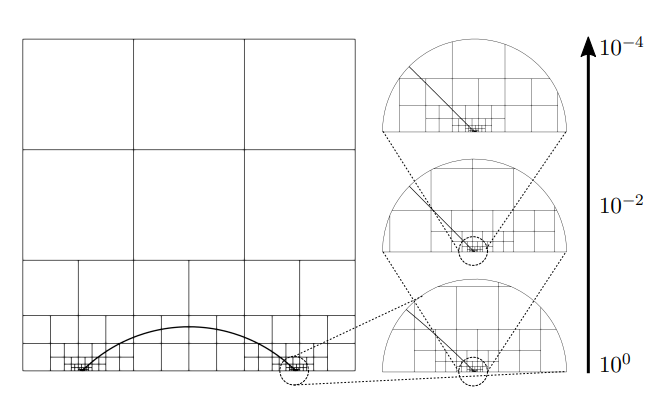

In the first test the droplet is assumed to be artificially fixed (held in place) and surface tension is turned off.  
This means an impermeability B.C. is employed at the interface in normal direction.  
The lower wall is dragged to the right and the amount of slip between fluid and wall is varied.  
This allows us to investigate the singularity arising in the corner flow.

In [ ]:
// Testcase setup - First series
// ==============
List<FreeXNSE_Control> controls = new List<FreeXNSE_Control>();
double R = 10.0;
double Theta = Math.PI/4.0;
double[] slipscalingS = new double[] {-1.0, 0.0, 1.0, 2.0};
foreach(int deg in degS){
foreach(int GridRes in GridResS){
foreach(double slipscaling in slipscalingS){
    var C = StaticDroplet_Base(GridRes, 20, deg, Math.PI/4.0, R);
    C.StaticDroplet_FixedInterface();
    C.SetBoundarySlip(slipscaling, 1.0);
    // C.SetContactLineSlip(0.0, 1.0);
    C.SetViscosity(0.0, 1.0);
    // C.SetContactAngle(Math.PI/4.0);
    controls.Add(C);
}
}
}
controls.ForEach(c => c.SessionName.Display());
ctrlCount += controls.Count();

In [ ]:
bool run      = true;
var bpc = BoSSSshell.GetDefaultQueue();

In [ ]:
//BoSSSshell.WorkflowMgm.ResetProject(true, true, true, true);

In [ ]:
// if(BoSSSshell.WorkflowMgm.AllJobs.Count() > 0){
//      BoSSSshell.WorkflowMgm.ResetProject();
// }
var jobs = controls.Select(c => c.CreateJob()).ToArray();
jobs.ForEach(j => j.NumberOfThreads = 1);
jobs.ForEach(j => j.EnvironmentVars["BOSSS_ARG_7"] = j.NumberOfThreads.ToString()); // large amount of simulations, this hack ensures that only one core is allocated per sim
jobs.Activate();

In the second testcase the droplet is not fixed anymore, but a free surface (Neumann B.C. with Laplace pressure due to surface tension) is assumed.  
Surface tension and a dynamic contact angle model is included.  
The contact angle is out of equilibrium $\theta_{stat} = 0$ vs. $\theta = \Pi/4$.  
This time singularities in the corner are not induced by an external forcing (movement of the wall) but by the intrinsic contact line movement.

In [ ]:
// Testcase setup - Second series
// ==============
List<FreeXNSE_Control> controls = new List<FreeXNSE_Control>();
double R = 10.0;
double Theta = Math.PI/4.0;
double[] slipscalingS = new double[] {-1.0, 0.0, 1.0};
double[] clslipS = new double[] {0.0, 1.0};

foreach(int deg in degS){
foreach(int GridRes in GridResS){
foreach(double slipscaling in slipscalingS){
foreach(double clslip in clslipS){
    var C = StaticDroplet_Base(GridRes, 20, deg, Math.PI/4.0, R);
    C.StaticDroplet_DynamicContactAngle();
    C.SetBoundarySlip(slipscaling, 1.0);
    C.SetContactLineSlip(1.0, clslip);
    C.SetViscosity(0.0, 1.0);
    C.SetContactAngle(0.0);
    controls.Add(C);
}
}
}
}
controls.ForEach(c => c.SessionName.Display());
ctrlCount += controls.Count();

In [ ]:
// if(BoSSSshell.WorkflowMgm.AllJobs.Count() > 0){
//      BoSSSshell.WorkflowMgm.ResetProject();
// }
var jobs = controls.Select(c => c.CreateJob()).ToArray();
jobs.ForEach(j => j.NumberOfThreads = 1);
jobs.ForEach(j => j.EnvironmentVars["BOSSS_ARG_7"] = j.NumberOfThreads.ToString());
jobs.Activate();

Same as the second testcase, but now additionally the viscosity is modeled to diverge at the contact line as $\mu \propto r^{\alpha}$.  
Thereby it is investigated wether a "solid-like" behavior at the contact line resolves the singularities.

In [ ]:
// Testcase setup - Third series
// ==============
List<FreeXNSE_Control> controls = new List<FreeXNSE_Control>();
double R = 10.0;
double Theta = Math.PI/4.0;
double[] slipscalingS = new double[] {-1.0, 0.0, 1.0};
double[] clslipS = new double[] {0.0, 1.0};
double[] viscosityscalingS = new double[] {-2.0, -1.0};

foreach(int deg in degS){
foreach(int GridRes in GridResS){
foreach(double slipscaling in slipscalingS){
foreach(double clslip in clslipS){
foreach(double viscosityscaling in viscosityscalingS){

    var C = StaticDroplet_Base(GridRes, 20, deg, Math.PI/4.0, R);
    C.StaticDroplet_DynamicContactAngle();
    C.SetBoundarySlip(slipscaling, 1.0);
    C.SetContactLineSlip(1.0, clslip);
    C.SetViscosity(viscosityscaling, 1.0);
    C.SetContactAngle(0.0);
    controls.Add(C);
}
}
}
}
}
controls.ForEach(c => c.SessionName.Display());
ctrlCount += controls.Count();

In [ ]:
// if(BoSSSshell.WorkflowMgm.AllJobs.Count() > 0){
//      BoSSSshell.WorkflowMgm.ResetProject();
// }
var jobs = controls.Select(c => c.CreateJob()).ToArray();
jobs.ForEach(j => j.NumberOfThreads = 1);
jobs.ForEach(j => j.EnvironmentVars["BOSSS_ARG_7"] = j.NumberOfThreads.ToString());
jobs.Activate();

Wait for simulations to finish and control if all finished successful

In [ ]:
BoSSSshell.WorkflowMgm.BlockUntilAllJobsTerminate(7200);

In [ ]:
int count = BoSSSshell.wmg.Sessions.Count();
int success = BoSSSshell.wmg.Sessions.Where(s => s.SuccessfulTermination).Count();

if(count != ctrlCount || count != success){
    throw new ApplicationException("Not all simulations calculated or finished successful!");
}